# Gradient checking with finite differences for a small neural network

We consider a binary classification problem based on two numerical features. Each point represents one observation, and the goal is to predict whether it belongs to class 0 or class 1. The two classes are arranged in a curved, nonlinearly separable pattern, so a simple linear model is not enough. In this notebook we train a **small neural network for binary classification** and use **finite differences** to check whether the implemented gradient is correct.

We work with:
- a **given 2D dataset** stored in `two_moons_nn_data.csv`,
- a neural network with **2 inputs**, **3 hidden tanh neurons**, and **1 sigmoid output**,
- the **binary cross-entropy** loss,
- an **exact gradient** obtained with the chain rule,
- a **numerical gradient** computed with central differences.


## Learning goals

By the end of the exercise you should be able to:
1. implement the forward pass of a small neural network for classification,
2. write the binary cross-entropy loss,
3. compute the gradient with respect to all parameters,
4. approximate the gradient numerically with finite differences,
5. compare both gradients using a relative error,
6. explain why gradient checking is useful in machine learning.


## 1. Load and visualize the dataset

The file `two_moons_nn_data.csv` contains three columns:
- `x1`
- `x2`
- `label`

The target `label` is binary, so this is a **classification** problem.


         x1        x2  label
0  0.251670 -0.032148      1
1 -0.344879  0.853045      0
2 -0.843236  0.408321      0
3  0.796518  0.686195      0
4 -0.183908  1.013603      0
X shape: (220, 2)
y shape: (220, 1)


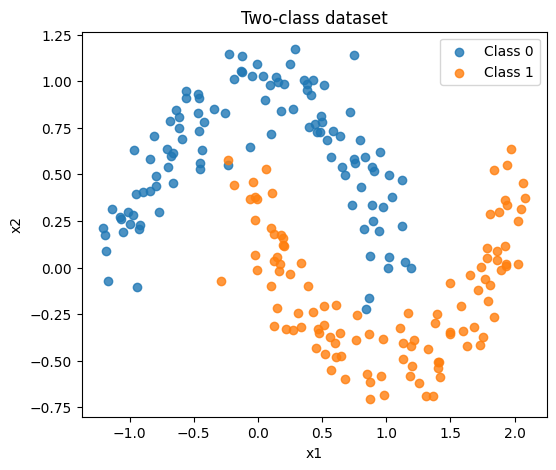

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/two_moons_nn_data.csv')
X = df[["x1", "x2"]].to_numpy(dtype=float)
y = df["label"].to_numpy(dtype=float).reshape(-1, 1)

print(df.head())
print("X shape:", X.shape)
print("y shape:", y.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], label="Class 0", alpha=0.8)
plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], label="Class 1", alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two-class dataset")
plt.legend()
plt.show()


## 2. Preprocess the inputs

To make optimization more stable, we standardize the two input features:

$$X_{\text{scaled}} = \frac{X - \mu}{\sigma}.$$

We will train the network on the standardized inputs, but still visualize the data in the original coordinates.


In [25]:
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)

X_scaled = (X - X_mean) / X_std

print("Mean after scaling:", X_scaled.mean(axis=0))
print("Std after scaling:", X_scaled.std(axis=0))


Mean after scaling: [ 8.07434927e-18 -4.03717464e-17]
Std after scaling: [1. 1.]


## 3. Model and parameter vector

We use the following neural network:

$$
A_1 = XW_1 + b_1,\qquad H = \tanh(A_1),
$$
$$
A_2 = HW_2 + b_2,\qquad \hat Y = \sigma(A_2),
$$

where:
- $W_1 \in \mathbb{R}^{2\times 3}$,
- $b_1 \in \mathbb{R}^{1\times 3}$,
- $W_2 \in \mathbb{R}^{3\times 1}$,
- $b_2 \in \mathbb{R}^{1\times 1}$.

To run gradient checking, we pack all parameters into a **single vector** $\theta \in \mathbb{R}^{13}$.


In [26]:
INPUT_DIM = 2
HIDDEN_DIM = 3
OUTPUT_DIM = 1

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def pack_parameters(W1, b1, W2, b2):
    return np.concatenate([W1.ravel(), b1.ravel(), W2.ravel(), b2.ravel()])

def unpack_parameters(theta, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM):
    idx = 0
    W1 = theta[idx:idx + input_dim * hidden_dim].reshape(input_dim, hidden_dim)
    idx += input_dim * hidden_dim

    b1 = theta[idx:idx + hidden_dim].reshape(1, hidden_dim)
    idx += hidden_dim

    W2 = theta[idx:idx + hidden_dim * output_dim].reshape(hidden_dim, output_dim)
    idx += hidden_dim * output_dim

    b2 = theta[idx:idx + output_dim].reshape(1, output_dim)
    return W1, b1, W2, b2

rng = np.random.default_rng(7)
theta0 = 0.4 * rng.standard_normal(INPUT_DIM * HIDDEN_DIM + HIDDEN_DIM + HIDDEN_DIM * OUTPUT_DIM + OUTPUT_DIM)
print("Number of parameters:", len(theta0))


Number of parameters: 13


## 4. Forward pass and loss

For a batch of inputs $X$, implement:
1. the forward pass,
2. the binary cross-entropy loss

$$
\mathcal{L}(\theta)=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i \log(\hat y_i) + (1-y_i)\log(1-\hat y_i)
\right].
$$

Use a small constant `eps` inside the logarithms for numerical stability.


In [27]:
def forward_pass(theta, X_batch):
    W1, b1, W2, b2 = unpack_parameters(theta)

    A1 = X_batch @ W1 + b1
    H = np.tanh(A1)
    A2 = H @ W2 + b2
    Y_hat = sigmoid(A2)

    return {"A1": A1, "H": H, "A2": A2, "Y_hat": Y_hat}

def binary_cross_entropy(theta, X_batch, y_batch, eps=1e-12):
    Y_hat = forward_pass(theta, X_batch)["Y_hat"]
    return -np.mean(y_batch * np.log(Y_hat + eps) + (1 - y_batch) * np.log(1 - Y_hat + eps))

print("Initial loss:", binary_cross_entropy(theta0, X_scaled, y))


Initial loss: 0.6952982512764966


## 5. Exact gradient

Using the chain rule, the output-layer derivative simplifies to

$$\frac{\partial \mathcal{L}}{\partial A_2}=
\frac{\hat Y - Y}{N}.$$

From there, compute the gradients of all parameters:
- $dW_2$, $db_2$,
- $dW_1$, $db_1$.

Return the full gradient as a vector with the same order used in `pack_parameters`.


In [28]:
def exact_gradient(theta, X_batch, y_batch):
    values = forward_pass(theta, X_batch)
    H = values["H"]
    Y_hat = values["Y_hat"]

    W1, b1, W2, b2 = unpack_parameters(theta)
    N = X_batch.shape[0]

    dA2 = (Y_hat - y_batch) / N
    dW2 = H.T @ dA2
    db2 = np.sum(dA2, axis=0, keepdims=True)

    dH = dA2 @ W2.T
    dA1 = dH * (1 - H**2)

    dW1 = X_batch.T @ dA1
    db1 = np.sum(dA1, axis=0, keepdims=True)

    return pack_parameters(dW1, db1, dW2, db2)

g0 = exact_gradient(theta0, X_scaled, y)
print("Gradient shape:", g0.shape)
print("First five components:", g0[:5])


Gradient shape: (13,)
First five components: [ 0.06253129 -0.04129009 -0.03538139 -0.07453606  0.0539634 ]


## 6. Numerical gradient with central differences

For each component $\theta_i$, approximate

$$
\frac{\partial \mathcal{L}}{\partial \theta_i}
\approx
\frac{\mathcal{L}(\theta + h e_i) - \mathcal{L}(\theta - h e_i)}{2h}.
$$

This method is slow, but it is very useful for **checking** an implementation.


In [29]:
def numerical_gradient_central(theta, X_batch, y_batch, h=1e-5):
    grad = np.zeros_like(theta, dtype=float)

    for i in range(len(theta)):
        e_i = np.zeros_like(theta, dtype=float)
        e_i[i] = 1.0

        grad[i] = (
            binary_cross_entropy(theta + h * e_i, X_batch, y_batch)
            - binary_cross_entropy(theta - h * e_i, X_batch, y_batch)
        ) / (2 * h)

    return grad


## 7. Gradient checking on a small batch

In practice, gradient checking is usually done on a **small batch** because it requires two loss evaluations **per parameter**.

Use the first 12 samples for the check and compare:
- the exact gradient,
- the numerical gradient,
- their absolute differences,
- the relative error

$$
\text{relative error}=
\frac{\lVert g_{\text{exact}} - g_{\text{num}} \rVert}
{\max(10^{-12}, \lVert g_{\text{exact}} \rVert + \lVert g_{\text{num}} \rVert)}.
$$


In [30]:
X_check = X_scaled[:12]
y_check = y[:12]

g_exact = exact_gradient(theta0, X_check, y_check)
g_num = numerical_gradient_central(theta0, X_check, y_check, h=1e-5)

comparison = pd.DataFrame({
    "parameter_index": np.arange(len(theta0)),
    "exact_gradient": g_exact,
    "numerical_gradient": g_num,
    "absolute_difference": np.abs(g_exact - g_num),
})

relative_error = np.linalg.norm(g_exact - g_num) / max(
    1e-12,
    np.linalg.norm(g_exact) + np.linalg.norm(g_num),
)

print(comparison.head(10))
print("\nMaximum absolute difference:", comparison["absolute_difference"].max())
print("Relative error:", relative_error)


   parameter_index  exact_gradient  numerical_gradient  absolute_difference
0                0        0.069499            0.069499         3.246875e-12
1                1       -0.056454           -0.056454         7.289218e-12
2                2       -0.038248           -0.038248         1.457133e-12
3                3       -0.067077           -0.067077         8.372747e-12
4                4        0.058736            0.058736         8.244141e-12
5                5        0.031420            0.031420         7.325876e-12
6                6       -0.100089           -0.100089         1.929013e-12
7                7        0.077252            0.077252         8.145207e-12
8                8        0.051499            0.051499         6.375067e-12
9                9       -0.096859           -0.096859         7.225817e-12

Maximum absolute difference: 8.693379349722363e-12
Relative error: 2.139013506829678e-11


## 8. Train the network

Once the gradient has been checked, we can use it for optimization.

Implement full-batch gradient descent:
1. compute the exact gradient,
2. update the parameter vector,
3. store the loss history.

Use:
- `lr = 0.2`
- `n_epochs = 5000`


In [31]:
def gradient_descent_step(theta, grad, lr):
    return theta - lr * grad

def train_network(theta_init, X_train, y_train, n_epochs, lr, record_every=50):
    theta = theta_init.copy()
    history = []

    for epoch in range(n_epochs):
        grad = exact_gradient(theta, X_train, y_train)
        theta = gradient_descent_step(theta, grad, lr)

        if epoch % record_every == 0 or epoch == n_epochs - 1:
            history.append(binary_cross_entropy(theta, X_train, y_train))

    return theta, np.array(history)

theta_fit, history = train_network(theta0, X_scaled, y, n_epochs=5000, lr=0.2)

y_prob = forward_pass(theta_fit, X_scaled)["Y_hat"]
y_pred = (y_prob >= 0.5).astype(int)
accuracy = np.mean(y_pred == y)

print("Final loss:", binary_cross_entropy(theta_fit, X_scaled, y))
print("Training accuracy:", accuracy)


Final loss: 0.0240729927300005
Training accuracy: 0.9954545454545455


## 9. Visualize the classifier

Plot:
1. the loss history,
2. the data points,
3. the decision boundary of the trained network.

To plot the boundary in the original coordinates, remember to standardize the grid before feeding it to the network.


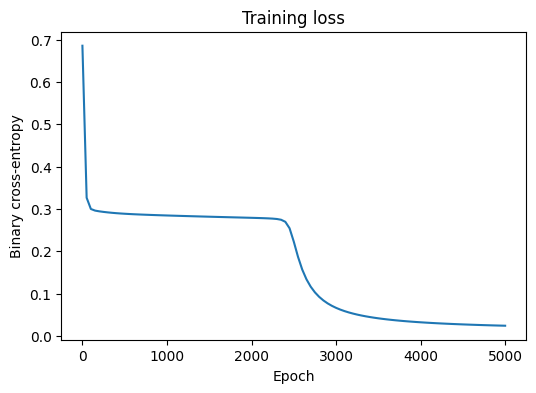

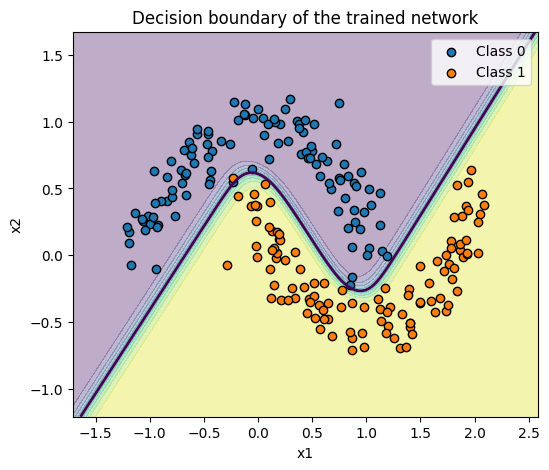

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(len(history)) * 50, history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Training loss")
plt.show()

def plot_decision_boundary(theta, X_original, y_true, X_mean, X_std, grid_points=250):
    x1_min, x1_max = X_original[:, 0].min() - 0.5, X_original[:, 0].max() + 0.5
    x2_min, x2_max = X_original[:, 1].min() - 0.5, X_original[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, grid_points),
        np.linspace(x2_min, x2_max, grid_points),
    )

    grid_original = np.column_stack([xx1.ravel(), xx2.ravel()])
    grid_scaled = (grid_original - X_mean) / X_std

    probs = forward_pass(theta, grid_scaled)["Y_hat"].reshape(xx1.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx1, xx2, probs, levels=np.linspace(0, 1, 11), alpha=0.35)
    plt.contour(xx1, xx2, probs, levels=[0.5], linewidths=2)

    plt.scatter(X_original[y_true[:, 0] == 0, 0], X_original[y_true[:, 0] == 0, 1], label="Class 0", edgecolor="k")
    plt.scatter(X_original[y_true[:, 0] == 1, 0], X_original[y_true[:, 0] == 1, 1], label="Class 1", edgecolor="k")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Decision boundary of the trained network")
    plt.legend()
    plt.show()

plot_decision_boundary(theta_fit, X, y, X_mean, X_std)


## 10. Effect of the step size

The finite-difference approximation depends on the step size $h$.

- If $h$ is too **large**, the approximation is inaccurate because of truncation error.
- If $h$ is too **small**, rounding errors can become visible.

Test several values of $h$ and study how the relative error changes.

              h  relative_error  max_absolute_difference
0  1.000000e-01    8.694877e-04             6.187988e-04
1  1.000000e-02    8.763713e-06             6.253990e-06
2  1.000000e-03    8.764435e-08             6.254661e-08
3  1.000000e-04    8.762889e-10             6.255269e-10
4  1.000000e-05    2.139014e-11             8.693379e-12
5  1.000000e-06    1.894881e-10             1.189823e-10
6  1.000000e-07    1.957210e-09             1.150222e-09
7  1.000000e-08    2.028952e-08             1.377149e-08


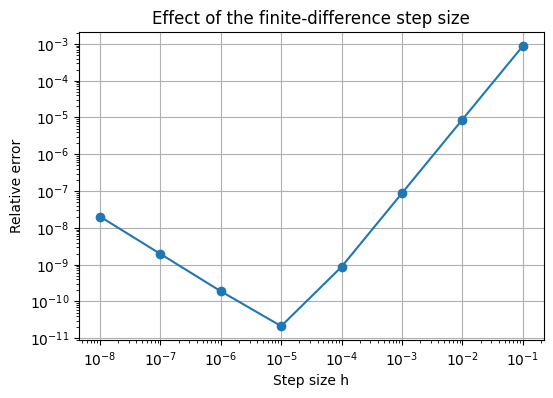

In [42]:
step_sizes = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]

rows = []
for h in step_sizes:
    g_num_h = numerical_gradient_central(theta0, X_check, y_check, h=h)
    rel_err_h = np.linalg.norm(g_exact - g_num_h) / max(
        1e-12,
        np.linalg.norm(g_exact) + np.linalg.norm(g_num_h),
    )
    rows.append({
        "h": h,
        "relative_error": rel_err_h,
        "max_absolute_difference": np.max(np.abs(g_exact - g_num_h)),
    })

step_size_results = pd.DataFrame(rows)
print(step_size_results)

plt.figure(figsize=(6, 4))
plt.loglog(step_size_results["h"], step_size_results["relative_error"], marker="o")
plt.xlabel("Step size h")
plt.ylabel("Relative error")
plt.title("Effect of the finite-difference step size")
plt.grid(True)
plt.show()

What do you observe? In many experiments, the error decreases at first as $h$ becomes smaller, but after a point it can increase again because of floating-point errors.

## 11. A buggy gradient

Finite differences are especially useful when the analytical gradient implementation contains a mistake.

In the next cell, define a **buggy gradient** by introducing a small error in the backpropagation formula. Then compare it with the numerical gradient on the same batch.

In [43]:
def buggy_gradient(theta, X_batch, y_batch):
    values = forward_pass(theta, X_batch)
    H = values["H"]
    Y_hat = values["Y_hat"]

    W1, b1, W2, b2 = unpack_parameters(theta)
    N = X_batch.shape[0]

    dA2 = (Y_hat - y_batch) / N
    dW2 = H.T @ dA2
    db2 = np.sum(dA2, axis=0, keepdims=True)

    dH = dA2 @ W2.T

    # BUG: the derivative of tanh should be (1 - H**2)
    dA1 = dH

    dW1 = X_batch.T @ dA1
    db1 = np.sum(dA1, axis=0, keepdims=True)

    return pack_parameters(dW1, db1, dW2, db2)

g_bug = buggy_gradient(theta0, X_check, y_check)

buggy_comparison = pd.DataFrame({
    "parameter_index": np.arange(len(theta0)),
    "buggy_gradient": g_bug,
    "numerical_gradient": g_num,
    "absolute_difference": np.abs(g_bug - g_num),
})

buggy_relative_error = np.linalg.norm(g_bug - g_num) / max(
    1e-12,
    np.linalg.norm(g_bug) + np.linalg.norm(g_num),
)

print(buggy_comparison.head(10))
print("\nMaximum absolute difference:", buggy_comparison["absolute_difference"].max())
print("Relative error with buggy gradient:", buggy_relative_error)

   parameter_index  buggy_gradient  numerical_gradient  absolute_difference
0                0        0.073365            0.069499         3.865942e-03
1                1       -0.057919           -0.056454         1.464247e-03
2                2       -0.042198           -0.038248         3.950615e-03
3                3       -0.078668           -0.067077         1.159158e-02
4                4        0.062106            0.058736         3.369964e-03
5                5        0.045249            0.031420         1.382862e-02
6                6       -0.109877           -0.100089         9.788380e-03
7                7        0.086744            0.077252         9.491930e-03
8                8        0.063200            0.051499         1.170038e-02
9                9       -0.096859           -0.096859         7.225817e-12

Maximum absolute difference: 0.01382861527689122
Relative error with buggy gradient: 0.024363989751971626


A large relative error now indicates that the analytical implementation is inconsistent with the numerical reference. This is exactly the kind of situation where gradient checking becomes valuable.

## 12. Discussion

**1. Why is gradient checking usually performed on a small batch rather than on the full dataset?**  
Because it is computationally expensive. For each parameter, central differences require two additional loss evaluations, so the total cost grows quickly with the number of parameters and with the batch size.

**2. What does a very small relative error tell us?**  
It suggests that the implemented exact gradient and the numerical gradient are almost identical. This is strong evidence that the gradient code is correct.

**3. Why is finite-difference gradient checking useful even when we already have an exact gradient formula?**  
Because implementation mistakes are common. Gradient checking provides an independent numerical reference that can reveal bugs in the forward pass, the loss, or the analytical gradient computation.
